<h1>Overview</h1>

The Fama-French 3-Factor Model is a financial framework that explains why stocks generate the returns they do. Instead of just looking at total returns, it breaks them down into components:

**The Core Idea:** Stock returns come from three main sources of risk:

1. **Market Risk (Beta)** - How much the stock moves with the overall market
   - High beta = amplifies market swings (riskier)
   - Low beta = dampens market swings (safer)
   <br>
2. **Size Risk (SMB - Small Minus Big)** - Whether the stock behaves like small companies or large companies
   - Small companies historically earn higher returns (but more volatile)
   - Positive SMB = behaves like small-cap stock
   <br>
3. **Value Risk (HML - High Minus Low)** - Whether the stock behaves like "value" or "growth" stocks
   - Value stocks = cheap, stable companies (banks, utilities)
   - Growth stocks = expensive, exciting companies (tech startups)
   - Positive HML = behaves like value stock, Negative HML = behaves like growth stock

This analysis applies the Fama-French model to 7 stocks across different sectors:
- **Technology:** AAPL, NVDA, MSFT
- **Financials:** JPM, GS  
- **Consumer/Energy:** WMT, XOM

We perform TWO types of analysis:
1. **Static Analysis** - One regression using all 10 years of data (2015-2025)
2. **Rolling Analysis** - 36-month moving windows to see how risk changed over time

**Key Question:** How do these stocks differ in their risk profiles, and have those risks changed over time?

<h1>Import Data and Libraries</h1>

In [1]:
import pandas as pd
import numpy as np

import pandas_datareader.data as web
import yfinance as yf

import statsmodels.api as sm

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

In [2]:
assets = ['AAPL', 'NVDA', 'MSFT', 'JPM', 'GS', 'WMT', 'XOM']
benchmark = '^GSPC'
start = '2015-01-01'
end = '2025-12-30'

In [3]:
benchmark_df = yf.download(tickers=benchmark, start=start, end=end)['Close'].resample('M').last().rename(columns={'^GSPC':'BM'})

benchmark_df.index = benchmark_df.index.to_period('M')

benchmark_df = benchmark_df.pct_change().dropna()

[*********************100%***********************]  1 of 1 completed


In [4]:
benchmark_df.head()

Ticker,BM
Date,
2015-02,0.054893
2015-03,-0.017396
2015-04,0.008521
2015-05,0.010491
2015-06,-0.021012


In [5]:
asset_df = yf.download(tickers=assets, start=start, end=end, timeout=50)['Close'].resample('M').last()

asset_df.index = asset_df.index.to_period('M')

asset_df = asset_df.pct_change().dropna()

asset_df = asset_df[assets]

[*********************100%***********************]  7 of 7 completed


In [6]:
asset_df.head()

Ticker,AAPL,NVDA,MSFT,JPM,GS,WMT,XOM
Date,,,,,,,
2015-02,0.100777,0.153382,0.093120,0.126885,0.104262,-0.012356,0.020435
2015-03,-0.031372,-0.051224,-0.072748,-0.011423,-0.009590,-0.014130,-0.039982
2015-04,0.005786,0.060678,0.196262,0.051179,0.044954,-0.051064,0.027882
2015-05,0.045339,0.001461,-0.030334,0.039836,0.053014,-0.042425,-0.016772
2015-06,-0.037227,-0.091279,-0.057832,0.030100,0.012610,-0.044971,-0.023474


French's data comes as percentages (e.g., 5.5 for 5.5%). We'll *divide* by **100** to get decimals (0.055) to match our stock returns format.

In [7]:
factors_df = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start, end=end)[0]

factors_df = factors_df.div(100)

#aligning the factor data with the asset and benchmark index
factors_df = factors_df.iloc[1:,]

In [8]:
print('Shape of Assets data:', asset_df.shape)
print('Shape of Benchmark data:', benchmark_df.shape)
print('Shape of Factor data:', factors_df.shape)

Shape of Assets data: (131, 7)
Shape of Benchmark data: (131, 1)
Shape of Factor data: (131, 4)


In [9]:
df = asset_df.join(factors_df)

In [10]:
df.head()

,AAPL,NVDA,MSFT,JPM,GS,WMT,XOM,Mkt-RF,SMB,HML,RF
Date,,,,,,,,,,,
2015-02,0.100777,0.153382,0.093120,0.126885,0.104262,-0.012356,0.020435,0.0613,0.0061,-0.0179,0.0
2015-03,-0.031372,-0.051224,-0.072748,-0.011423,-0.009590,-0.014130,-0.039982,-0.0111,0.0305,-0.0038,0.0
2015-04,0.005786,0.060678,0.196262,0.051179,0.044954,-0.051064,0.027882,0.0059,-0.0299,0.0180,0.0
2015-05,0.045339,0.001461,-0.030334,0.039836,0.053014,-0.042425,-0.016772,0.0137,0.0095,-0.0111,0.0
2015-06,-0.037227,-0.091279,-0.057832,0.030100,0.012610,-0.044971,-0.023474,-0.0152,0.0294,-0.0082,0.0


In [11]:
print(df.isna().sum())
df.describe()

AAPL      0
NVDA      0
MSFT      0
JPM       0
GS        0
WMT       0
XOM       0
Mkt-RF    0
SMB       0
HML       0
RF        0
dtype: int64


,AAPL,NVDA,MSFT,JPM,GS,WMT,XOM,Mkt-RF,SMB,HML,RF
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,0.021151,0.055547,0.022292,0.018303,0.017633,0.013666,0.008924,0.010195,-0.001803,-0.000909,0.001596
std,0.078419,0.133197,0.062177,0.068753,0.082436,0.054224,0.076262,0.044850,0.027579,0.037267,0.001615
min,-0.181198,-0.320274,-0.109267,-0.224615,-0.230014,-0.156170,-0.261858,-0.133700,-0.059300,-0.138300,0.000000
25%,-0.035127,-0.025370,-0.016678,-0.028307,-0.042204,-0.018053,-0.025169,-0.013150,-0.023000,-0.021500,0.000100
50%,0.023183,0.056196,0.020791,0.023382,0.016282,0.014803,0.007855,0.013700,-0.002000,-0.004700,0.001200
75%,0.076974,0.139171,0.061529,0.059228,0.071902,0.049031,0.043795,0.034050,0.012900,0.019400,0.003350
max,0.216569,0.385446,0.196262,0.215371,0.234121,0.128737,0.269156,0.136000,0.071400,0.128600,0.004800


The Fama-French model explains **EXCESS returns**, not *total returns*.
$$
    Excess \ Return  = Asset \ Return - Risk\text- Free\text- Rate
$$

We create new columns with `_exc` suffix to keep original returns for reference.

In [12]:
for col in assets:
    df[f'{col}_exc'] = df[col]-df['RF']

In [13]:
df.head()

,AAPL,NVDA,MSFT,JPM,GS,WMT,XOM,Mkt-RF,SMB,HML,RF,AAPL_exc,NVDA_exc,MSFT_exc,JPM_exc,GS_exc,WMT_exc,XOM_exc
Date,,,,,,,,,,,,,,,,,,
2015-02,0.100777,0.153382,0.093120,0.126885,0.104262,-0.012356,0.020435,0.0613,0.0061,-0.0179,0.0,0.100777,0.153382,0.093120,0.126885,0.104262,-0.012356,0.020435
2015-03,-0.031372,-0.051224,-0.072748,-0.011423,-0.009590,-0.014130,-0.039982,-0.0111,0.0305,-0.0038,0.0,-0.031372,-0.051224,-0.072748,-0.011423,-0.009590,-0.014130,-0.039982
2015-04,0.005786,0.060678,0.196262,0.051179,0.044954,-0.051064,0.027882,0.0059,-0.0299,0.0180,0.0,0.005786,0.060678,0.196262,0.051179,0.044954,-0.051064,0.027882
2015-05,0.045339,0.001461,-0.030334,0.039836,0.053014,-0.042425,-0.016772,0.0137,0.0095,-0.0111,0.0,0.045339,0.001461,-0.030334,0.039836,0.053014,-0.042425,-0.016772
2015-06,-0.037227,-0.091279,-0.057832,0.030100,0.012610,-0.044971,-0.023474,-0.0152,0.0294,-0.0082,0.0,-0.037227,-0.091279,-0.057832,0.030100,0.012610,-0.044971,-0.023474


In [14]:
dependent = df.columns[-7:]

In [15]:
dependent

Index(['AAPL_exc', 'NVDA_exc', 'MSFT_exc', 'JPM_exc', 'GS_exc', 'WMT_exc',
       'XOM_exc'],
      dtype='object')

For each stock, run one regression using ALL 131 months of data. The regression equation is:
$$
    Excess \ Return = \alpha + \beta(Mkt-RF) + s(SMB) + h(HML) + error
$$

In [16]:
result = []
for i in dependent:
    y = df[i]
    
    X = df[['Mkt-RF', 'SMB', 'HML']]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    beta = model.params
    pvalues = model.pvalues

    result.append({
        "Asset": i,
        'Alpha': beta['const'],
        'Market_beta': beta['Mkt-RF'],
        'Value_beta': beta['HML'],
        'Size_beta': beta['SMB'],

        'Alpha_pval': pvalues['const'],
        'Market_pval': pvalues['Mkt-RF'],
        'Value_pval': pvalues['HML'],
        'Size_pval': pvalues['SMB'],

        'R_squared': model.rsquared  
    })

Each coefficient tells us:**
- **Alpha ($\alpha$):** Risk-adjusted outperformance. Positive & significant = beat expectations
- **Beta ($\beta$ ):** Market sensitivity. $\beta$ > 1 = amplifies market moves (high risk)
- **SMB (s):** Size exposure. Positive = behaves like small-cap
- **HML (h):** Value exposure. Positive = behaves like value stock, negative = growth

In [17]:
factor_score = pd.DataFrame(result).set_index('Asset').sort_values(by='Value_beta', ascending=False)
factor_score

,Alpha,Market_beta,Value_beta,Size_beta,Alpha_pval,Market_pval,Value_pval,Size_pval,R_squared
Asset,,,,,,,,,
XOM_exc,-0.000541,0.860049,1.041185,-0.026656,0.912319,3.164946e-12,3.510929e-13,0.883872,0.507530
JPM_exc,0.006113,1.120541,0.797144,0.058161,0.061435,2.055921e-30,2.695997e-16,0.629372,0.734235
GS_exc,0.003472,1.341607,0.692637,0.267452,0.414422,2.504425e-27,5.662048e-09,0.091626,0.683806
WMT_exc,0.005572,0.542156,-0.161422,-0.456853,0.206666,2.712918e-07,1.618115e-01,0.005839,0.210218
AAPL_exc,0.006908,1.176220,-0.445607,-0.139057,0.184168,9.961231e-18,1.270036e-03,0.470231,0.481521
MSFT_exc,0.008504,1.043250,-0.487371,-0.617288,0.017722,5.113676e-25,5.678388e-07,0.000007,0.614189
NVDA_exc,0.034794,1.760489,-0.965358,-0.183638,0.000285,1.247574e-13,1.226049e-04,0.596464,0.415126


**Key findings:**
- Sorted by Value_beta to show the value ↔ growth spectrum
- XOM and JPM are value stocks (positive HML)
- NVDA and MSFT are growth stocks (negative HML)
- Statistical significance varies - not all coefficients are meaningful

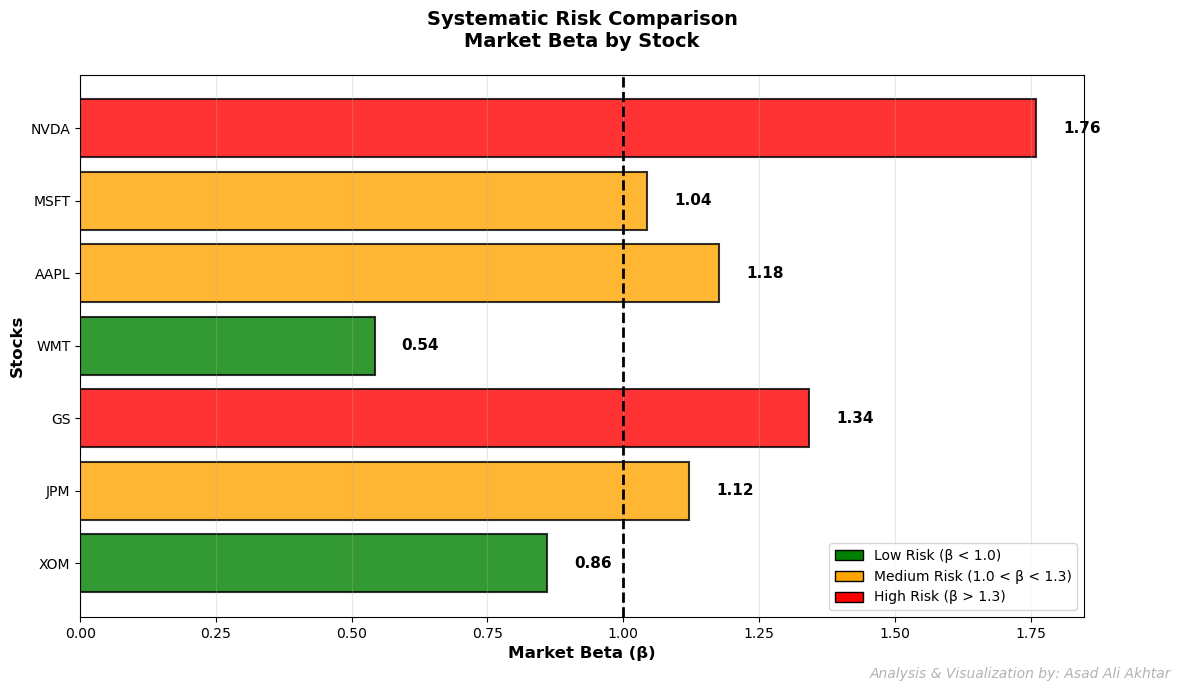

In [18]:
stocks = factor_score.index.str.replace('_exc', '')
betas = factor_score['Market_beta'].values

# Create color based on risk level
colors = ['red' if b > 1.3 else 'orange' if b > 1.0 else 'green' for b in betas]

# Create plot
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(stocks, betas, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add reference line at beta = 1
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=2, label='Market Beta = 1.0')

# Labels
ax.set_xlabel('Market Beta (β)', fontsize=12, fontweight='bold')
ax.set_ylabel('Stocks', fontsize=12, fontweight='bold')
ax.set_title('Systematic Risk Comparison\nMarket Beta by Stock', 
             fontsize=14, fontweight='bold', pad=20)

# Add value labels
for i, (bar, beta) in enumerate(zip(bars, betas)):
    width = bar.get_width()
    ax.text(width + 0.05, bar.get_y() + bar.get_height()/2,
            f'{beta:.2f}',
            ha='left', va='center', fontsize=11, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='Low Risk (β < 1.0)'),
    Patch(facecolor='orange', edgecolor='black', label='Medium Risk (1.0 < β < 1.3)'),
    Patch(facecolor='red', edgecolor='black', label='High Risk (β > 1.3)')
]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')

ax.grid(True, alpha=0.3, axis='x')

plt.text(0.98, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar',
         fontsize=10,
         color='gray',
         ha='right',
         va='bottom',
         alpha=0.6,
         fontstyle='italic',
         transform=plt.gcf().transFigure)  # Use figure coordinates

plt.tight_layout()
plt.savefig('Systematic_Risk_Comparison_plot.jpg')
plt.show()

**Beta** is the most important risk measure in finance. This chart displays the systematic risk profile of seven stocks using market beta **($\beta$)** from the Fama-French regression analysis.<br>
The analysis reveals *NVDA* as the *highest-risk* stock.

The static regression assumes factor exposures are CONSTANT over 10 years. But *Companies evolve* (Apple went from hardware to services), *Market regimes change* (COVID, rate cycles, AI boom), and *Risk profiles shift* over time.<br>
I'm using 36-months rolling window to see the changes of factors over time.

In [19]:
# ============================================
# ROLLING WINDOW FAMA-FRENCH REGRESSION
# ============================================

# Parameters
window_size = 36  # 3 years
dependent = df.columns[-7:]  # Your 7 stock excess returns

# Storage for results
rolling_results = {}

# Loop through each stock
for stock in dependent:
    
    # Storage for this stock's rolling coefficients
    dates = []
    alphas = []
    betas = []
    smb_coefs = []
    hml_coefs = []
    r_squareds = []
    
    # Rolling window loop
    for i in range(len(df) - window_size + 1):
        # Get window data
        window_data = df.iloc[i:i+window_size]
        
        # Prepare regression
        y = window_data[stock]
        X = window_data[['Mkt-RF', 'SMB', 'HML']]
        X = sm.add_constant(X)
        
        # Run regression
        model = sm.OLS(y, X).fit()
        
        # Store results
        dates.append(window_data.index[-1])  # End date of window
        alphas.append(model.params['const'])
        betas.append(model.params['Mkt-RF'])
        smb_coefs.append(model.params['SMB'])
        hml_coefs.append(model.params['HML'])
        r_squareds.append(model.rsquared)
    
    # Store in dictionary
    rolling_results[stock] = pd.DataFrame({
        'Date': dates,
        'Alpha': alphas,
        'Beta': betas,
        'SMB': smb_coefs,
        'HML': hml_coefs,
        'R_squared': r_squareds
    }).set_index('Date')

print("\nRolling regression complete!")
print(f"Total windows per stock: {len(dates)}")


Rolling regression complete!
Total windows per stock: 96


In [20]:
# Check one stock's results
stock_to_check = 'NVDA_exc'
print(f"\n{stock_to_check} Rolling Results:")
print(rolling_results[stock_to_check].head())
print(f"\nShape: {rolling_results[stock_to_check].shape}")
print(f"Date range: {rolling_results[stock_to_check].index[0]} to {rolling_results[stock_to_check].index[-1]}")


NVDA_exc Rolling Results:
            Alpha      Beta       SMB       HML  R_squared
Date                                                      
2018-01  0.061108  1.571810 -0.110967  0.428169   0.164512
2018-02  0.060413  1.587775 -0.122642  0.442821   0.169346
2018-03  0.061138  1.593413 -0.107633  0.428722   0.174990
2018-04  0.058838  1.616881 -0.198487  0.454264   0.175427
2018-05  0.061644  1.632462 -0.047950  0.324869   0.179244

Shape: (96, 5)
Date range: 2018-01 to 2025-12


I'm plotting line chart of market beta **($\beta$ )** over time for 4 selected stocks. The reason for only using 4 stocks is to reduce clutter.

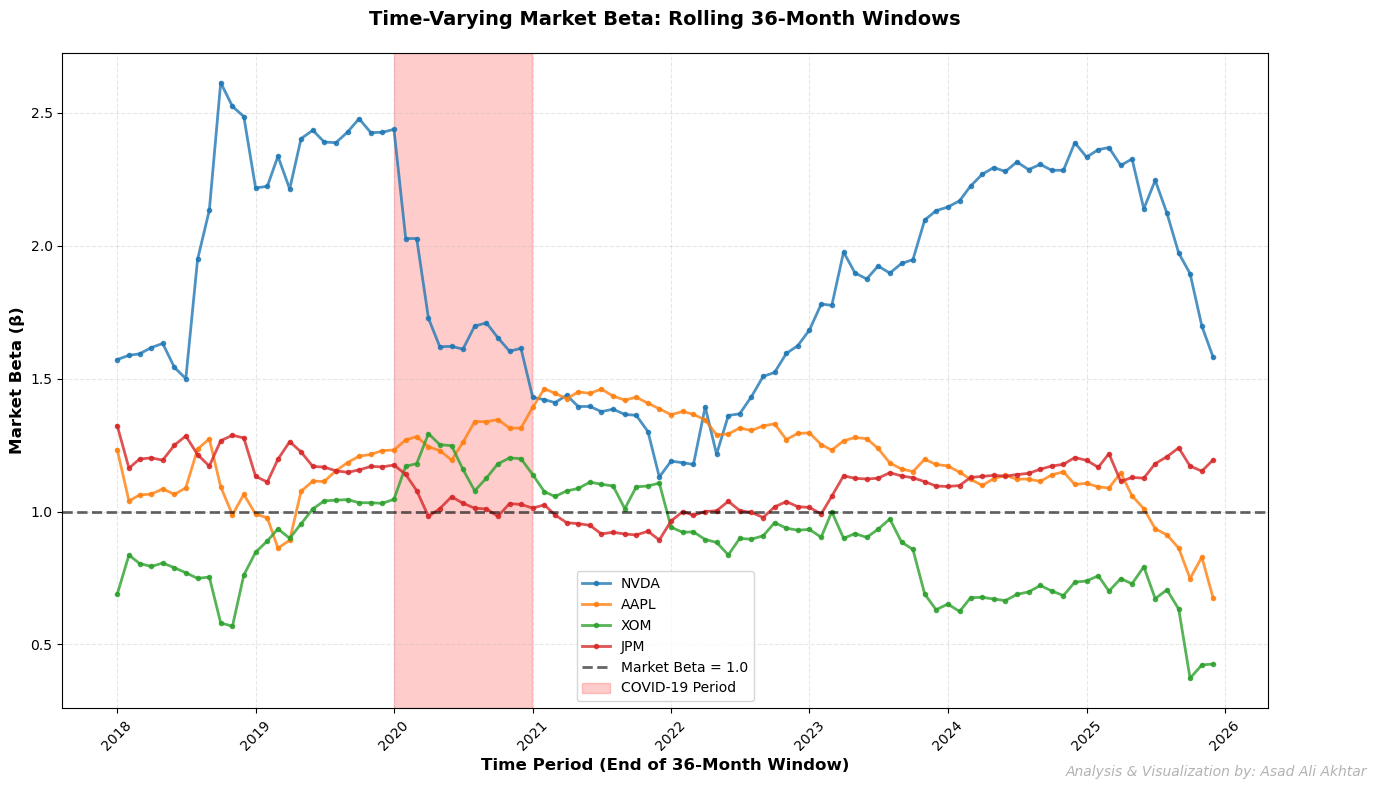

In [21]:
# Pick 3-4 most interesting ones
stocks_to_plot = ['NVDA_exc', 'AAPL_exc', 'XOM_exc', 'JPM_exc']

# Create figure
plt.figure(figsize=(14, 8))

# Plot rolling beta for each stock
for stock in stocks_to_plot:
    stock_name = stock.replace('_exc', '')
    plt.plot(rolling_results[stock].index.to_timestamp(), 
             rolling_results[stock]['Beta'],
             label=stock_name, linewidth=2, marker='o', markersize=3, alpha=0.8)

# Add reference line at beta = 1
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2, 
            label='Market Beta = 1.0', alpha=0.6)

# Add shaded region for COVID period (example of adding context)
plt.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2020-12-31'), 
            alpha=0.2, color='red', label='COVID-19 Period')

# Labels and formatting
plt.xlabel('Time Period (End of 36-Month Window)', fontsize=12, fontweight='bold')
plt.ylabel('Market Beta (β)', fontsize=12, fontweight='bold')
plt.title('Time-Varying Market Beta: Rolling 36-Month Windows', 
          fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)

plt.text(0.98, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar',
         fontsize=10,
         color='gray',
         ha='right',
         va='bottom',
         alpha=0.6,
         fontstyle='italic',
         transform=plt.gcf().transFigure)  # Use figure coordinates

plt.tight_layout()
plt.savefig("Time_varying_Market_beta_plot.jpg")
plt.show()

The rolling beta analysis reveals significant time variation in systematic risk. *NVDA* exhibits the highest instability. <br>
*JPM* maintains remarkably stable beta around 1.0 throughout the period. The COVID-19 period temporarily disrupted *beta* relationships across all stocks.

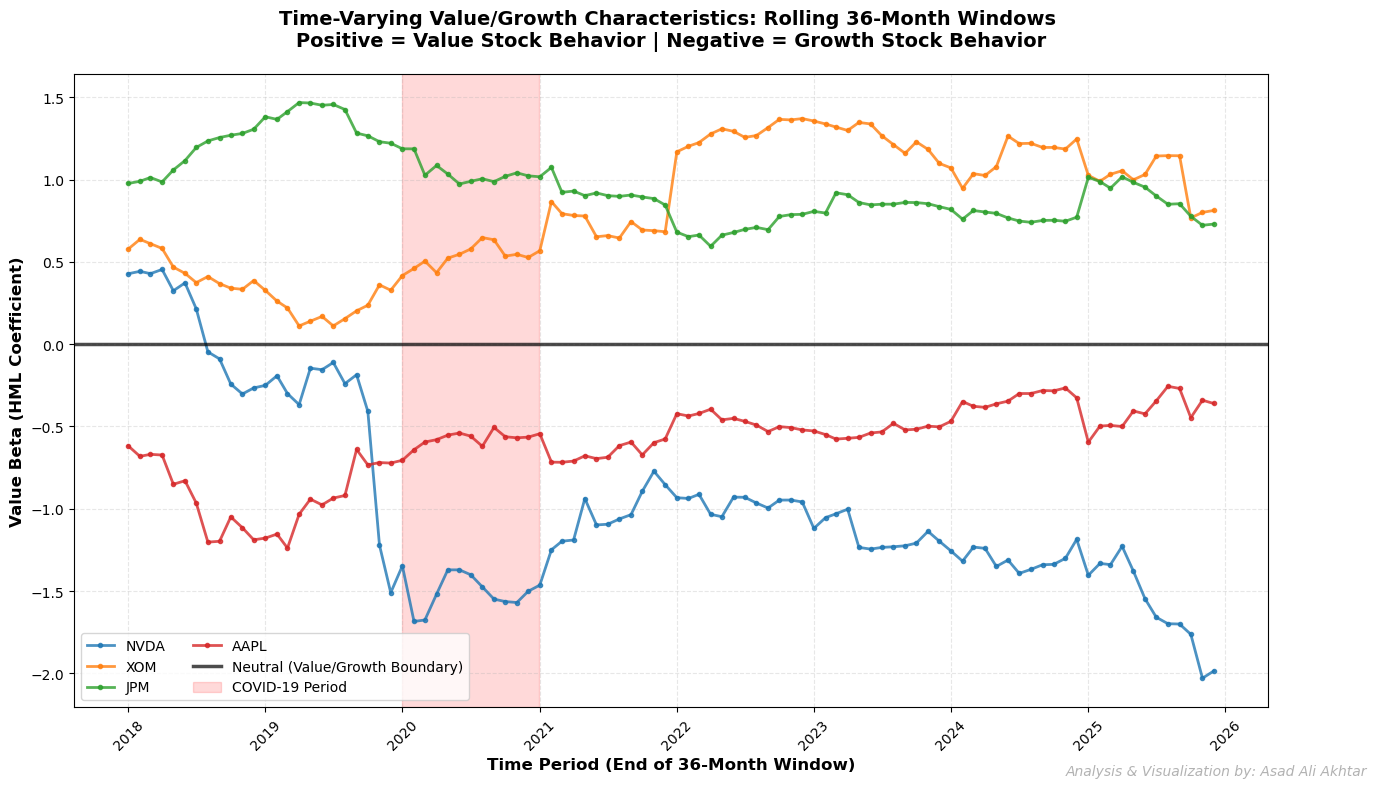

In [22]:
# ============================================
# ROLLING VALUE BETA (HML) OVER TIME
# ============================================

# Select stocks to display (pick interesting ones with different value/growth profiles)
stocks_to_plot = ['NVDA_exc', 'XOM_exc', 'JPM_exc', 'AAPL_exc']

# Create figure
plt.figure(figsize=(14, 8))

# Plot rolling HML for each stock
for stock in stocks_to_plot:
    stock_name = stock.replace('_exc', '')
    plt.plot(rolling_results[stock].index.to_timestamp(), 
             rolling_results[stock]['HML'],
             label=stock_name, linewidth=2, marker='o', markersize=3, alpha=0.8)

# Add reference line at HML = 0 (value/growth dividing line)
plt.axhline(y=0, color='black', linestyle='-', linewidth=2.5, 
            label='Neutral (Value/Growth Boundary)', alpha=0.7)

# Add context - COVID period
plt.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2020-12-31'), 
            alpha=0.15, color='red', label='COVID-19 Period')

# Labels and formatting
plt.xlabel('Time Period (End of 36-Month Window)', fontsize=12, fontweight='bold')
plt.ylabel('Value Beta (HML Coefficient)', fontsize=12, fontweight='bold')
plt.title('Time-Varying Value/Growth Characteristics: Rolling 36-Month Windows \nPositive = Value Stock Behavior | Negative = Growth Stock Behavior', 
          fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=10, loc='best', ncol=2)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)

plt.text(0.98, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar',
         fontsize=10,
         color='gray',
         ha='right',
         va='bottom',
         alpha=0.6,
         fontstyle='italic',
         transform=plt.gcf().transFigure)  # Use figure coordinates

plt.tight_layout()
plt.savefig("Value_Growth_Charac_plot.jpg")
plt.show()

The line chart of HML coefficient over time shows whether stocks became more *value-oriented* or *growth-oriented*.

**Key Findings:**

1. **Risk Heterogeneity:** Stocks exhibit vastly different systematic risk profiles - NVDA (β=1.76, high volatility) vs WMT (β=0.54, defensive) vs JPM (β=1.12, market-average).

2. **Style Segmentation:** Clear value/growth divide: Energy and Financials show value characteristics (positive HML), while Tech stocks demonstrate strong growth orientation (negative HML).

3. **Time-Varying Risk:** Static beta masks significant variation - NVDA's beta ranged from 1.2 to 2.6 over the period, demonstrating that risk is NOT constant.

4. **COVID Impact:** All stocks experienced temporary beta disruption during 2020, with subsequent normalization but altered trajectories post-pandemic.


**Practical Implications:**
Portfolio construction should account for both static factor exposures and their time-variation. Low-beta stocks (WMT, XOM) provide diversification benefits, while high-beta stocks (NVDA, GS) amplify returns in bull markets but increase downside risk.

**Limitations:**
Limited to 7 large-cap stocks; results may not generalize to broader market. Factor premiums historically observed may not persist. Alpha may reflect missing factors rather than genuine outperformance.